In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
transaction = pd.read_excel("QVI_transaction_data.xlsx")
customer = pd.read_csv("QVI_purchase_behaviour.csv")

In [6]:
transaction.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [7]:
transaction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


In [8]:
transaction.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264836.000000,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,43464.036260,135.08011,1.355495e+05,1.351583e+05,56.583157,1.907309,7.304200
std,105.389282,76.78418,8.057998e+04,7.813303e+04,32.826638,0.643654,3.083226
min,43282.000000,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,43373.000000,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,43464.000000,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,43555.000000,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,43646.000000,272.00000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000


In [9]:
transaction.isnull().sum()

DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

In [10]:
transaction.tail()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
264831,43533,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8
264832,43325,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4
264833,43410,272,272379,270187,51,Doritos Mexicana 170g,2,8.8
264834,43461,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8
264835,43365,272,272380,270189,74,Tostitos Splash Of Lime 175g,2,8.8


In [11]:
transaction.columns

Index(['DATE', 'STORE_NBR', 'LYLTY_CARD_NBR', 'TXN_ID', 'PROD_NBR',
       'PROD_NAME', 'PROD_QTY', 'TOT_SALES'],
      dtype='object')

In [12]:
transaction["PROD_QTY"].value_counts().sort_index()

PROD_QTY
1       27518
2      236039
3         430
4         397
5         450
200         2
Name: count, dtype: int64

In [13]:
transaction["PROD_QTY"].describe()

count    264836.000000
mean          1.907309
std           0.643654
min           1.000000
25%           2.000000
50%           2.000000
75%           2.000000
max         200.000000
Name: PROD_QTY, dtype: float64

In [15]:
transaction[transaction["PROD_QTY"]==200]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,43331,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,43605,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0


In [16]:
transaction.loc[transaction["LYLTY_CARD_NBR"]==226000]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,43331,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,43605,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0


In [18]:
transaction["PROD_NAME"].sort_values().unique()

array(['Burger Rings 220g', 'CCs Nacho Cheese    175g',
       'CCs Original 175g', 'CCs Tasty Cheese    175g',
       'Cheetos Chs & Bacon Balls 190g', 'Cheetos Puffs 165g',
       'Cheezels Cheese 330g', 'Cheezels Cheese Box 125g',
       'Cobs Popd Sea Salt  Chips 110g',
       'Cobs Popd Sour Crm  &Chives Chips 110g',
       'Cobs Popd Swt/Chlli &Sr/Cream Chips 110g',
       'Dorito Corn Chp     Supreme 380g',
       'Doritos Cheese      Supreme 330g',
       'Doritos Corn Chip Mexican Jalapeno 150g',
       'Doritos Corn Chip Southern Chicken 150g',
       'Doritos Corn Chips  Cheese Supreme 170g',
       'Doritos Corn Chips  Nacho Cheese 170g',
       'Doritos Corn Chips  Original 170g', 'Doritos Mexicana    170g',
       'Doritos Salsa       Medium 300g', 'Doritos Salsa Mild  300g',
       'French Fries Potato Chips 175g',
       'Grain Waves         Sweet Chilli 210g',
       'Grain Waves Sour    Cream&Chives 210G',
       'GrnWves Plus Btroot & Chilli Jam 180g',
       'Infuzi

In [19]:
non_chip_products = [
    "Old El Paso Salsa   Dip Tomato Mild 300g",
    "Old El Paso Salsa   Dip Chnky Tom Ht300g",
    "Old El Paso Salsa   Dip Tomato Med 300g",
    "Woolworths Mild     Salsa 300g",
    "Woolworths Medium   Salsa 300g",
]

In [24]:
transaction = transaction[
    ~transaction["PROD_NAME"].isin(non_chip_products)]

In [26]:
print("Shape after removing non-chip dip products:", transaction.shape)

Shape after removing non-chip dip products: (252591, 8)


In [28]:
print("Duplicate rows found:", transaction.duplicated().sum())


Duplicate rows found: 1


In [29]:
transaction = transaction.drop_duplicates()

In [31]:
print("Shape after removing duplicates:", transaction.shape)

Shape after removing duplicates: (252590, 8)


In [32]:
transaction = transaction[transaction["LYLTY_CARD_NBR"] != 226000]
print("Shape after removing outlier customer:", transaction.shape)

Shape after removing outlier customer: (252588, 8)


In [33]:
transaction["DATE"] = pd.to_datetime(
    transaction["DATE"], unit="D", origin="1899-12-30"
)

In [34]:
print(transaction["DATE"].min(), transaction["DATE"].max())

2018-07-01 00:00:00 2019-06-30 00:00:00


In [35]:
transaction["PACK_SIZE"] = (
    transaction["PROD_NAME"].str.extract(r"(\d+)").astype(int)
)

In [36]:
print(transaction[["PROD_NAME", "PACK_SIZE"]].head())
print(transaction["PACK_SIZE"].describe())

                                  PROD_NAME  PACK_SIZE
0    Natural Chip        Compny SeaSalt175g        175
1                  CCs Nacho Cheese    175g        175
2    Smiths Crinkle Cut  Chips Chicken 170g        170
3    Smiths Chip Thinly  S/Cream&Onion 175g        175
4  Kettle Tortilla ChpsHny&Jlpno Chili 150g        150
count    252588.000000
mean        176.725747
std          60.296686
min          70.000000
25%         150.000000
50%         170.000000
75%         175.000000
max         380.000000
Name: PACK_SIZE, dtype: float64


In [37]:
transaction["BRAND"] = transaction["PROD_NAME"].str.split().str[0]

transaction["BRAND"] = transaction["BRAND"].replace({
    "Red": "RRD",
    "Dorito": "Doritos",
    "Smith": "Smiths",
    "Snbts": "Sunbites",
    "Infzns": "Infuzions",
    "WW": "Woolworths",
    "Natural": "Natural Chip Company",
    "NCC": "Natural Chip Company",
    "Grain": "Grain Waves",
    "GrnWves": "Grain Waves",
})



In [38]:
print(transaction["BRAND"].value_counts())

BRAND
Kettle                  41288
Smiths                  31822
Doritos                 28145
Pringles                25102
RRD                     17779
Infuzions               14201
Thins                   14075
Woolworths              11836
Cobs                     9693
Tostitos                 9471
Twisties                 9454
Grain Waves              7740
Natural Chip Company     7469
Tyrrells                 6442
Cheezels                 4603
CCs                      4551
Sunbites                 3008
Cheetos                  2927
Burger                   1564
French                   1418
Name: count, dtype: int64


In [39]:
customer.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [40]:
customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [41]:
customer.isnull().sum()

LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [42]:
customer["LIFESTAGE"].unique()

array(['YOUNG SINGLES/COUPLES', 'YOUNG FAMILIES', 'OLDER SINGLES/COUPLES',
       'MIDAGE SINGLES/COUPLES', 'NEW FAMILIES', 'OLDER FAMILIES',
       'RETIREES'], dtype=object)

In [43]:
customer["PREMIUM_CUSTOMER"].unique()

array(['Premium', 'Mainstream', 'Budget'], dtype=object)

In [44]:
print("Duplicate loyalty cards:", customer["LYLTY_CARD_NBR"].duplicated().sum())

Duplicate loyalty cards: 0


In [45]:
merged_data = pd.merge(
    transaction,
    customer,
    on="LYLTY_CARD_NBR",
    how="left"
)

In [46]:
print("Merged shape:", merged_data.shape)

Merged shape: (252588, 12)


In [47]:
print(merged_data.isnull().sum())

DATE                0
STORE_NBR           0
LYLTY_CARD_NBR      0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
PACK_SIZE           0
BRAND               0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64


In [48]:
merged_data.to_csv("QVI_merged_clean.csv", index=False)
print("Saved!")

Saved!


## KPIs 

In [54]:
total_sales = merged_data["TOT_SALES"].sum()
print("Total Sales: $", round(total_sales, 2))

Total Sales: $ 1834039.4


In [55]:
total_customers = merged_data["LYLTY_CARD_NBR"].nunique()
print("Total Customers:", total_customers)

Total Customers: 71733


In [56]:
total_txns = merged_data["TXN_ID"].nunique()
print("Total Transactions:", total_txns)

Total Transactions: 251035


In [57]:
avg_spend_per_txn = total_sales / total_txns
print("Avg Spend per Transaction: $", round(avg_spend_per_txn, 2))

Avg Spend per Transaction: $ 7.31


In [58]:
avg_qty_per_txn = merged_data["PROD_QTY"].sum() / total_txns
print("Avg Qty per Transaction:", round(avg_qty_per_txn, 2))

Avg Qty per Transaction: 1.92


LIFESTAGE
OLDER SINGLES/COUPLES     381787.35
RETIREES                  347198.30
OLDER FAMILIES            334932.80
YOUNG FAMILIES            300079.20
YOUNG SINGLES/COUPLES     246953.30
MIDAGE SINGLES/COUPLES    175167.50
NEW FAMILIES               47920.95
Name: TOT_SALES, dtype: float64


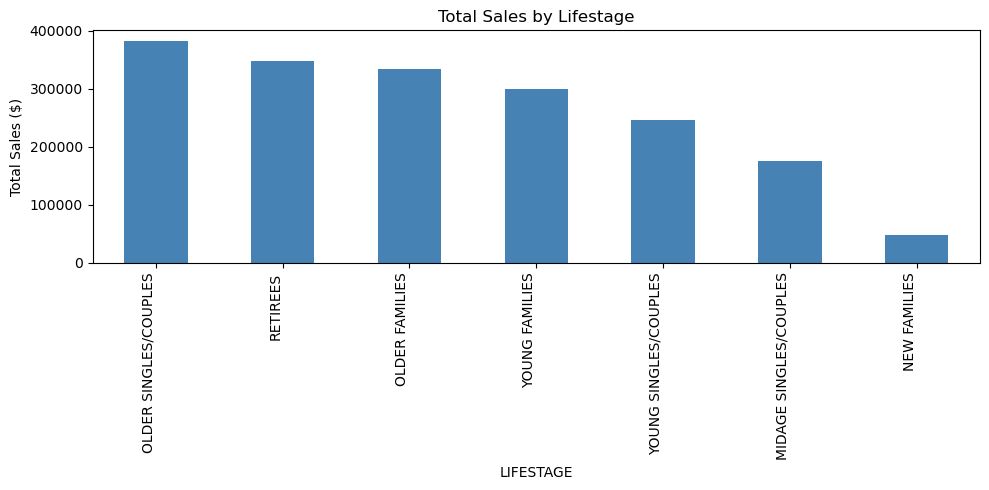

In [61]:
sales_lifestage = merged_data.groupby("LIFESTAGE")["TOT_SALES"].sum().sort_values(ascending=False)
print(sales_lifestage)

sales_lifestage.plot(kind="bar", figsize=(10,5), color="steelblue")
plt.title("Total Sales by Lifestage")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=90, ha="right")
plt.tight_layout()
plt.show()

LIFESTAGE
OLDER SINGLES/COUPLES     381787.35
RETIREES                  347198.30
OLDER FAMILIES            334932.80
YOUNG FAMILIES            300079.20
YOUNG SINGLES/COUPLES     246953.30
MIDAGE SINGLES/COUPLES    175167.50
NEW FAMILIES               47920.95
Name: TOT_SALES, dtype: float64


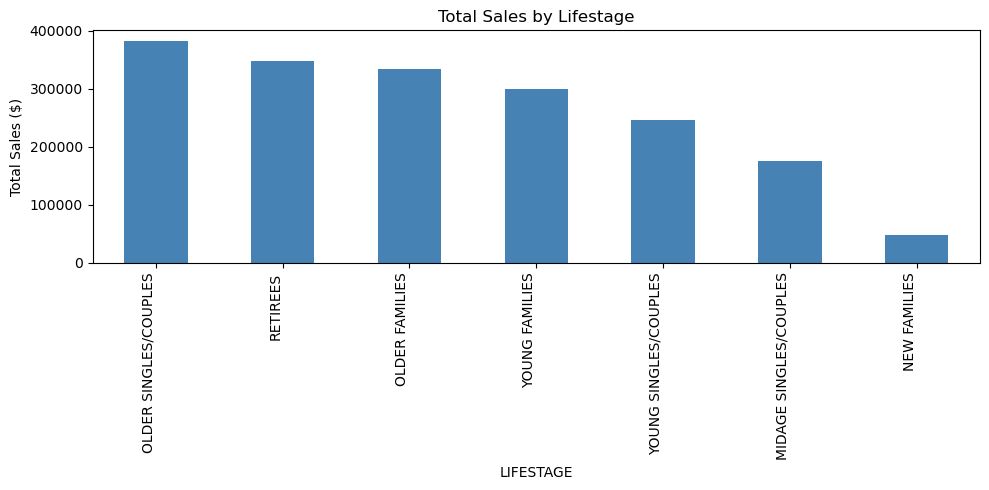

In [63]:
sales_lifestage = merged_data.groupby("LIFESTAGE")["TOT_SALES"].sum().sort_values(ascending=False)
print(sales_lifestage)

sales_lifestage.plot(kind="bar", figsize=(10,5), color="steelblue")
plt.title("Total Sales by Lifestage")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=90, ha="right")
plt.tight_layout()
plt.show()

LIFESTAGE               PREMIUM_CUSTOMER
OLDER FAMILIES          Budget              159989.35
YOUNG SINGLES/COUPLES   Mainstream          149117.20
RETIREES                Mainstream          147444.15
YOUNG FAMILIES          Budget              132055.25
OLDER SINGLES/COUPLES   Budget              129671.80
                        Mainstream          126803.10
                        Premium             125312.45
RETIREES                Budget              107313.40
OLDER FAMILIES          Mainstream           98240.25
RETIREES                Premium              92440.75
YOUNG FAMILIES          Mainstream           88145.65
MIDAGE SINGLES/COUPLES  Mainstream           85665.75
YOUNG FAMILIES          Premium              79878.30
OLDER FAMILIES          Premium              76703.20
YOUNG SINGLES/COUPLES   Budget               58139.80
MIDAGE SINGLES/COUPLES  Premium              55533.75
YOUNG SINGLES/COUPLES   Premium              39696.30
MIDAGE SINGLES/COUPLES  Budget           

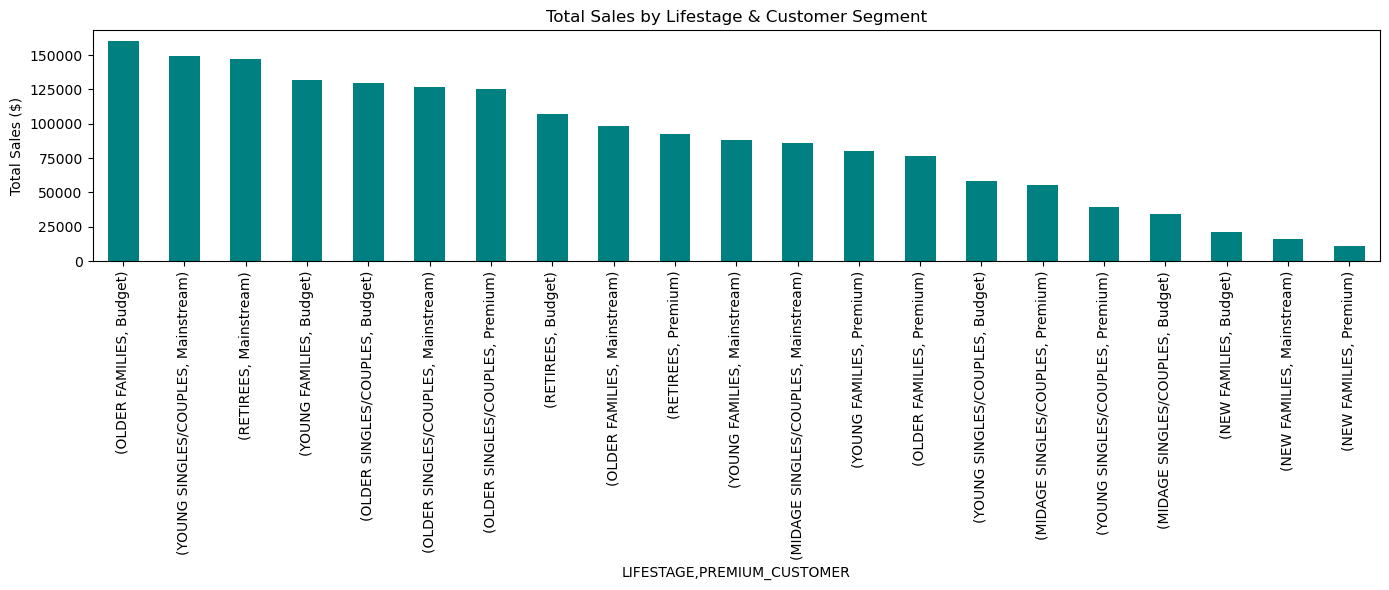

In [68]:
segment_sales = merged_data.groupby(
    ["LIFESTAGE", "PREMIUM_CUSTOMER"]
)["TOT_SALES"].sum().sort_values(ascending=False)

print(segment_sales)

segment_sales.plot(kind="bar", figsize=(14,6), color="teal")
plt.title("Total Sales by Lifestage & Customer Segment")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

LIFESTAGE               PREMIUM_CUSTOMER
YOUNG SINGLES/COUPLES   Mainstream          7943
RETIREES                Mainstream          6400
OLDER SINGLES/COUPLES   Mainstream          4883
                        Budget              4878
                        Premium             4709
OLDER FAMILIES          Budget              4635
RETIREES                Budget              4408
YOUNG FAMILIES          Budget              3968
RETIREES                Premium             3826
YOUNG SINGLES/COUPLES   Budget              3702
MIDAGE SINGLES/COUPLES  Mainstream          3305
OLDER FAMILIES          Mainstream          2800
YOUNG FAMILIES          Mainstream          2697
YOUNG SINGLES/COUPLES   Premium             2520
YOUNG FAMILIES          Premium             2411
MIDAGE SINGLES/COUPLES  Premium             2397
OLDER FAMILIES          Premium             2247
MIDAGE SINGLES/COUPLES  Budget              1492
NEW FAMILIES            Budget              1096
                        Main

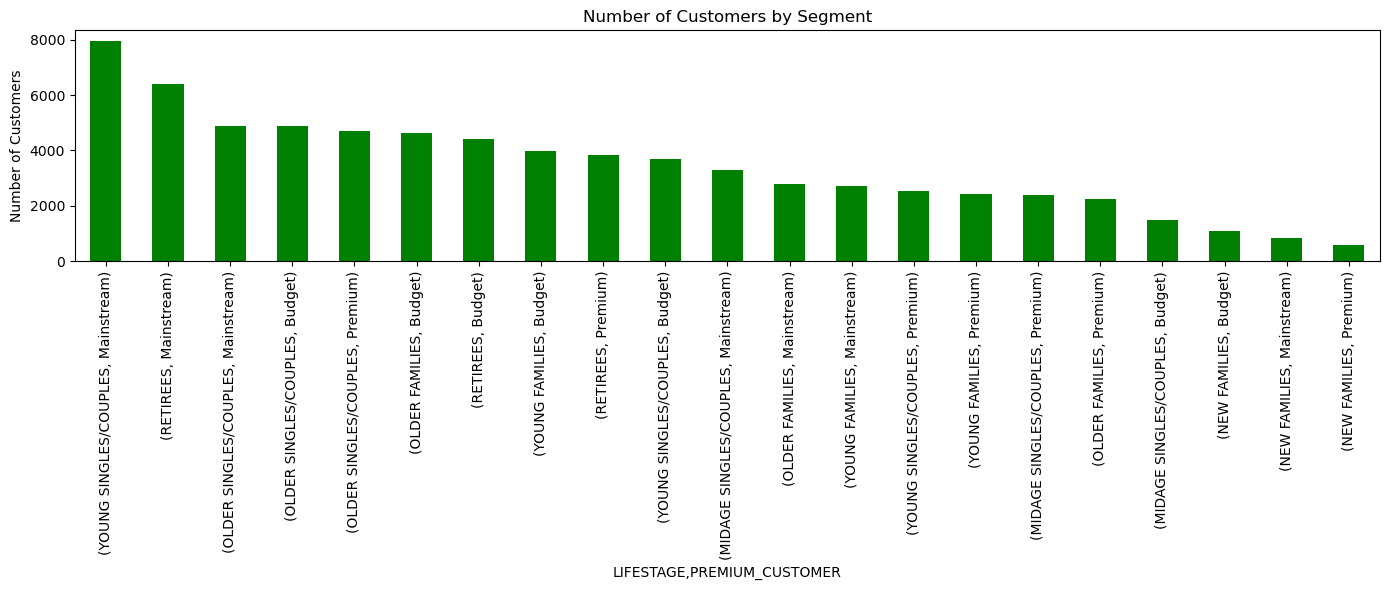

In [69]:
customer_count = merged_data.groupby(
    ["LIFESTAGE","PREMIUM_CUSTOMER"]
)["LYLTY_CARD_NBR"].nunique().sort_values(ascending=False)

print(customer_count)

customer_count.plot(kind="bar", figsize=(14,6), color="green")
plt.title("Number of Customers by Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

LIFESTAGE               PREMIUM_CUSTOMER
OLDER FAMILIES          Mainstream          35.085804
                        Budget              34.517659
                        Premium             34.135826
YOUNG FAMILIES          Budget              33.280053
                        Premium             33.130776
                        Mainstream          32.682851
OLDER SINGLES/COUPLES   Premium             26.611266
                        Budget              26.582985
                        Mainstream          25.968278
MIDAGE SINGLES/COUPLES  Mainstream          25.920045
RETIREES                Budget              24.345145
                        Premium             24.161200
MIDAGE SINGLES/COUPLES  Premium             23.168023
RETIREES                Mainstream          23.038148
MIDAGE SINGLES/COUPLES  Budget              22.766756
NEW FAMILIES            Mainstream          19.328469
                        Budget              19.013002
                        Premium          

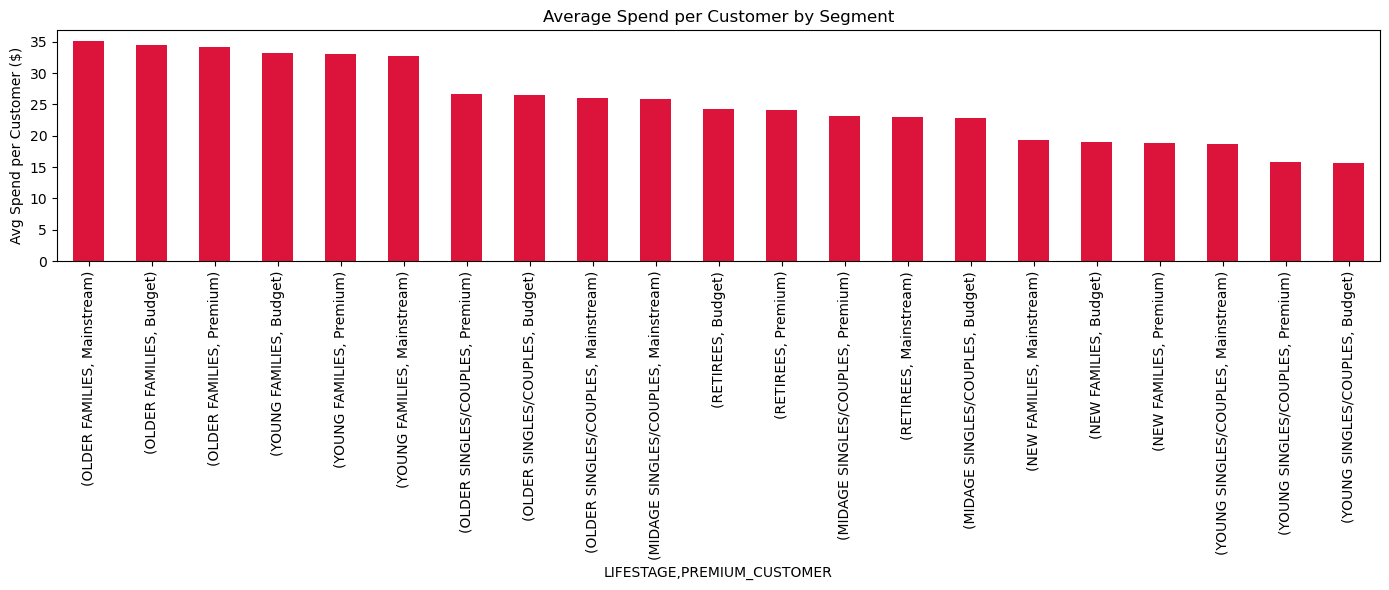

In [70]:
avg_spend_per_cust = (
    merged_data.groupby(["LIFESTAGE","PREMIUM_CUSTOMER"])["TOT_SALES"].sum()
    / merged_data.groupby(["LIFESTAGE","PREMIUM_CUSTOMER"])["LYLTY_CARD_NBR"].nunique()
).sort_values(ascending=False)

print(avg_spend_per_cust)

avg_spend_per_cust.plot(kind="bar", figsize=(14,6), color="crimson")
plt.title("Average Spend per Customer by Segment")
plt.ylabel("Avg Spend per Customer ($)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [71]:
target = merged_data[
    (merged_data["LIFESTAGE"]=="YOUNG SINGLES/COUPLES") &
    (merged_data["PREMIUM_CUSTOMER"]=="Mainstream")
]

rest = merged_data[
    ~((merged_data["LIFESTAGE"]=="YOUNG SINGLES/COUPLES") &
      (merged_data["PREMIUM_CUSTOMER"]=="Mainstream"))
]

target_brand_share = target.groupby("BRAND")["PROD_QTY"].sum() / target["PROD_QTY"].sum()
rest_brand_share = rest.groupby("BRAND")["PROD_QTY"].sum() / rest["PROD_QTY"].sum()

affinity = (target_brand_share / rest_brand_share).sort_values(ascending=False)
print(affinity)

BRAND
Tyrrells                1.237592
Twisties                1.228748
Kettle                  1.205144
Tostitos                1.204959
Pringles                1.195847
Doritos                 1.168457
Cobs                    1.151963
Infuzions               1.142199
Thins                   1.067615
Grain Waves             1.056984
Cheezels                0.971206
Smiths                  0.768405
French                  0.690871
Cheetos                 0.670881
RRD                     0.663877
Natural Chip Company    0.640153
CCs                     0.596252
Sunbites                0.508601
Woolworths              0.491344
Burger                  0.447027
Name: PROD_QTY, dtype: float64


In [73]:
target_pack_share = target.groupby("PACK_SIZE")["PROD_QTY"].sum() / target["PROD_QTY"].sum()
rest_pack_share = rest.groupby("PACK_SIZE")["PROD_QTY"].sum() / rest["PROD_QTY"].sum()

pack_affinity = (target_pack_share / rest_pack_share).sort_values(ascending=False)
print(pack_affinity)

PACK_SIZE
270    1.278095
380    1.266750
330    1.231164
134    1.195847
110    1.192790
210    1.168283
135    1.138245
250    1.131851
170    1.005082
175    0.951701
150    0.950164
165    0.900668
300    0.698833
190    0.605920
180    0.596113
160    0.521618
90     0.508601
125    0.502297
200    0.484618
70     0.484006
220    0.447027
Name: PROD_QTY, dtype: float64


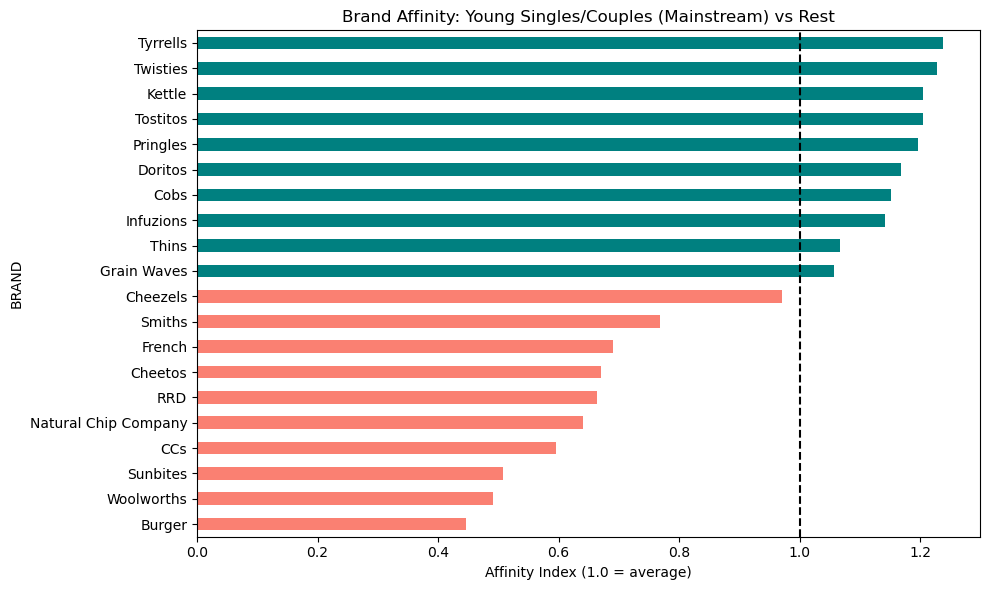

In [74]:
plt.figure(figsize=(10,6))
colors = ["teal" if v>=1 else "salmon" for v in affinity.values]
affinity.plot(kind="barh", color=colors)
plt.axvline(1.0, color="black", linestyle="--")
plt.title("Brand Affinity: Young Singles/Couples (Mainstream) vs Rest")
plt.xlabel("Affinity Index (1.0 = average)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

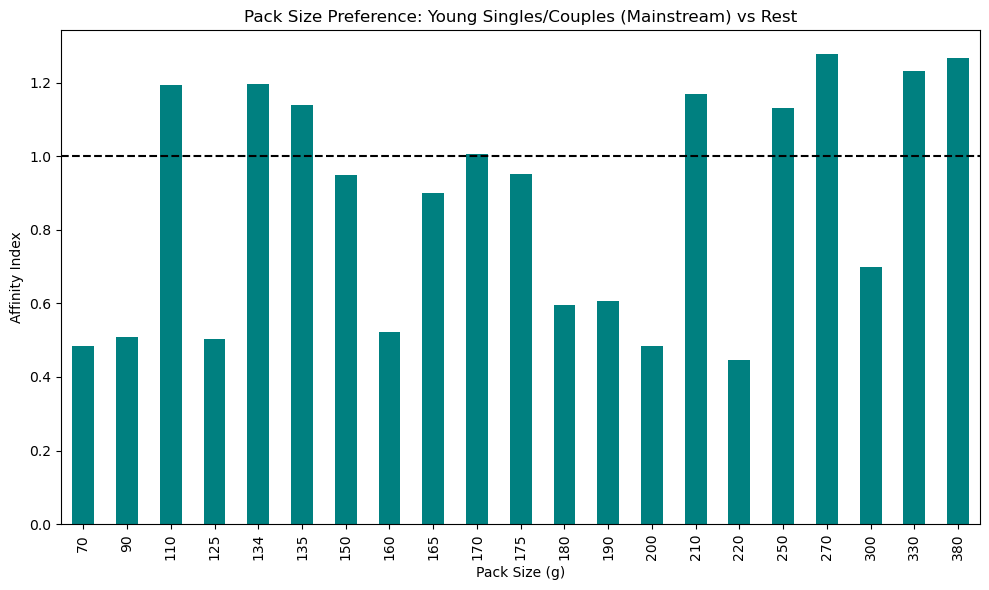

In [75]:
plt.figure(figsize=(10,6))
colors2 = ["teal" if v>=1 else "salmon" for v in pack_affinity.values]
pack_affinity.sort_index().plot(kind="bar", color="teal")
plt.title("Pack Size Preference: Young Singles/Couples (Mainstream) vs Rest")
plt.ylabel("Affinity Index")
plt.axhline(1.0, color="black", linestyle="--")
plt.xlabel("Pack Size (g)")
plt.tight_layout()
plt.show()

## Key Findings & Commercial Recommendation

**Overall category performance:**
- Total sales: $1,834,039 across 71,733 customers and 251,035 transactions
  
- Average spend per transaction: $7.31, average 1.92 units per transaction

**Which segments drive sales, and how:**
- Young Singles/Couples (Mainstream) has the largest customer base (7,943) and generates 
  $149,117 in sales — but their average spend per customer ($18.77) is below average. 
  Their contribution is driven by VOLUME (many customers), not high spend per customer.
- Older Families (Mainstream) has far fewer customers (2,697) but the highest average spend 
  per customer ($35.09) of any segment — a high-VALUE segment.
- Retirees (Mainstream) sits in between: a large customer base (6,400) with solid average 
  spend ($23.03), making it the second-largest total sales contributor.

**Deep dive — Young Singles/Couples (Mainstream):**
- Over-indexes strongly on Tyrrells, Twisties, Kettle, Tostitos, Pringles and Doritos 
  (17-24% more likely to buy these vs. rest of the customer base)
- Strongly prefers large pack sizes: 270g, 380g, 330g (23-28% higher affinity)
- Under-indexes on Woolworths, Burger Rings, Sunbites and small pack sizes (70g-90g)

**Commercial Recommendation for Julia:**
1. Prioritise Young Singles/Couples (Mainstream) and Retirees (Mainstream) as the two 
   target segments for the next half-year chip category plan — combined they represent 
   the largest customer base and close to $300k in sales.
2. For Young Singles/Couples: stock and promote large-format packs (270g-380g) of 
   Tyrrells, Kettle, Doritos and Twisties — this segment is chasing volume/value packs 
   from these specific brands.
3. Because this segment's revenue is driven by customer count rather than high spend per 
   head, loyalty and acquisition campaigns are likely to have more impact than trying to 
   upsell existing customers to premium products.
4. Older Families (Mainstream), while a smaller customer base, has the highest spend per 
   customer — worth a separate targeted premium offer to protect this high-value segment.
5. New Families is the smallest segment across every price tier and is not recommended 
   as a priority target for this cycle.